In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
df.duplicated().sum() #القيم المكرره

np.int64(0)

In [6]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [7]:
df['race/ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [8]:
df['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [9]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [10]:
df.columns = (
    df.columns.str.strip().str.lower().str.replace(' ','_').str.replace('/','_')
)
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [11]:
df.gender.unique()

array(['female', 'male'], dtype=object)

In [12]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
reading_full=df[df.reading_score == 100].reading_score.count()
math_full=df[df.math_score == 100].math_score.count()
writing_full=df[df.writing_score == 100].writing_score.count()
print(f'reading_full:{reading_full}')
print(f'math_full:{math_full}')
print(f'writing_full:{writing_full}')

reading_full:17
math_full:7
writing_full:14


In [14]:
number=[100,99,98,97,96,95]

reading_full=df[df.reading_score >= 95].reading_score.count()
math_full=df[df.math_score.isin(number)].math_score.count()
writing_full=df[df.writing_score.isin(number)].writing_score.count()

print(f'reading_full:{reading_full}')
print(f'math_full:{math_full}')
print(f'writing_full:{writing_full}')

reading_full:37
math_full:24
writing_full:34


In [15]:
pass_grid = 50

df['pass_math'] = 'yes'
filt= (df.math_score < pass_grid)
df.loc[filt , 'pass_math'] = 'no'

df['pass_reading'] = 'yes'
filt= (df.reading_score < pass_grid)
df.loc[filt , 'pass_reading'] = 'no'

df['pass_writing'] = 'yes'
filt= (df.writing_score < pass_grid)
df.loc[filt , 'pass_writing'] = 'no'

df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,pass_math,pass_reading,pass_writing
0,female,group B,bachelor's degree,standard,none,72,72,74,yes,yes,yes
1,female,group C,some college,standard,completed,69,90,88,yes,yes,yes
2,female,group B,master's degree,standard,none,90,95,93,yes,yes,yes
3,male,group A,associate's degree,free/reduced,none,47,57,44,no,yes,no
4,male,group C,some college,standard,none,76,78,75,yes,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,yes,yes,yes
996,male,group C,high school,free/reduced,none,62,55,55,yes,yes,yes
997,female,group C,high school,free/reduced,completed,59,71,65,yes,yes,yes
998,female,group D,some college,standard,completed,68,78,77,yes,yes,yes


In [16]:
good =df[df.math_score >= 50].math_score.count()
print(good)

good2 = df.groupby('pass_math').math_score.count()
print(good2)


865
pass_math
no     135
yes    865
Name: math_score, dtype: int64


 average score in math is :66.089 
 average score in reading is :69.169 
 average score in writing is :68.054 



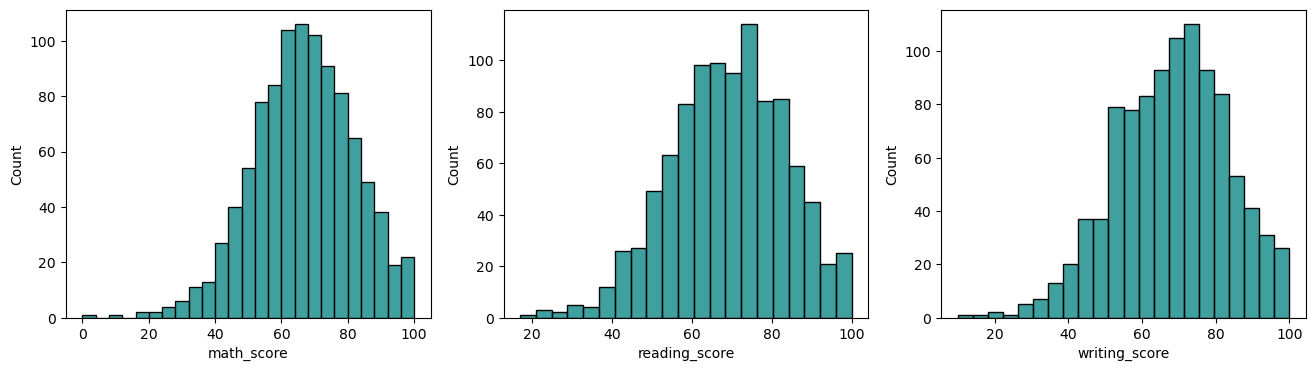

In [43]:
fig , ax = plt.subplots(1,3 ,figsize=(16,4))

sns.histplot(x= 'math_score' , data=df , ax=ax[0] , color='teal')
sns.histplot(x= 'reading_score' , data=df , ax=ax[1] , color='teal')
sns.histplot(x= 'writing_score' , data=df , ax=ax[2] , color='teal')

math_mean = df.math_score.mean()
reading_mean = df.reading_score.mean()
writing_mean = df.writing_score.mean()

print(f' average score in math is :{math_mean} \n average score in reading is :{reading_mean} \n average score in writing is :{writing_mean} \n')
plt.show()


pass_math
no     135
yes    865
Name: pass_math, dtype: int64
pass_reading
no      90
yes    910
Name: pass_reading, dtype: int64
pass_writing
no     114
yes    886
Name: pass_writing, dtype: int64


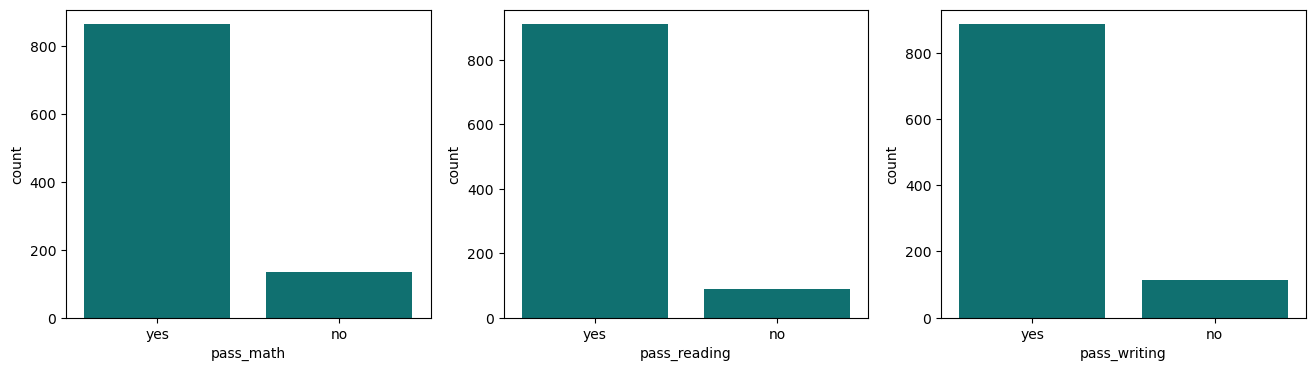

In [52]:
fig , ax = plt.subplots(1,3 ,figsize=(16,4))
sns.countplot(x= 'pass_math' , data=df , ax=ax[0] , color='teal')
sns.countplot(x= 'pass_reading' , data=df , ax=ax[1] , color='teal')
sns.countplot(x= 'pass_writing' , data=df , ax=ax[2] , color='teal')

math_count = df.groupby('pass_math')['pass_math'].count()
reading_count = df.groupby('pass_reading')['pass_reading'].count()
writing_count = df.groupby('pass_writing')['pass_writing'].count()


print(math_count)
print(reading_count)
print(writing_count)

In [93]:
s =df.test_preparation_course.unique()
print(f'{s} \n================================')
size = df['test_preparation_course'].value_counts()
print(size)

['none' 'completed'] 
test_preparation_course
none         642
completed    358
Name: count, dtype: int64


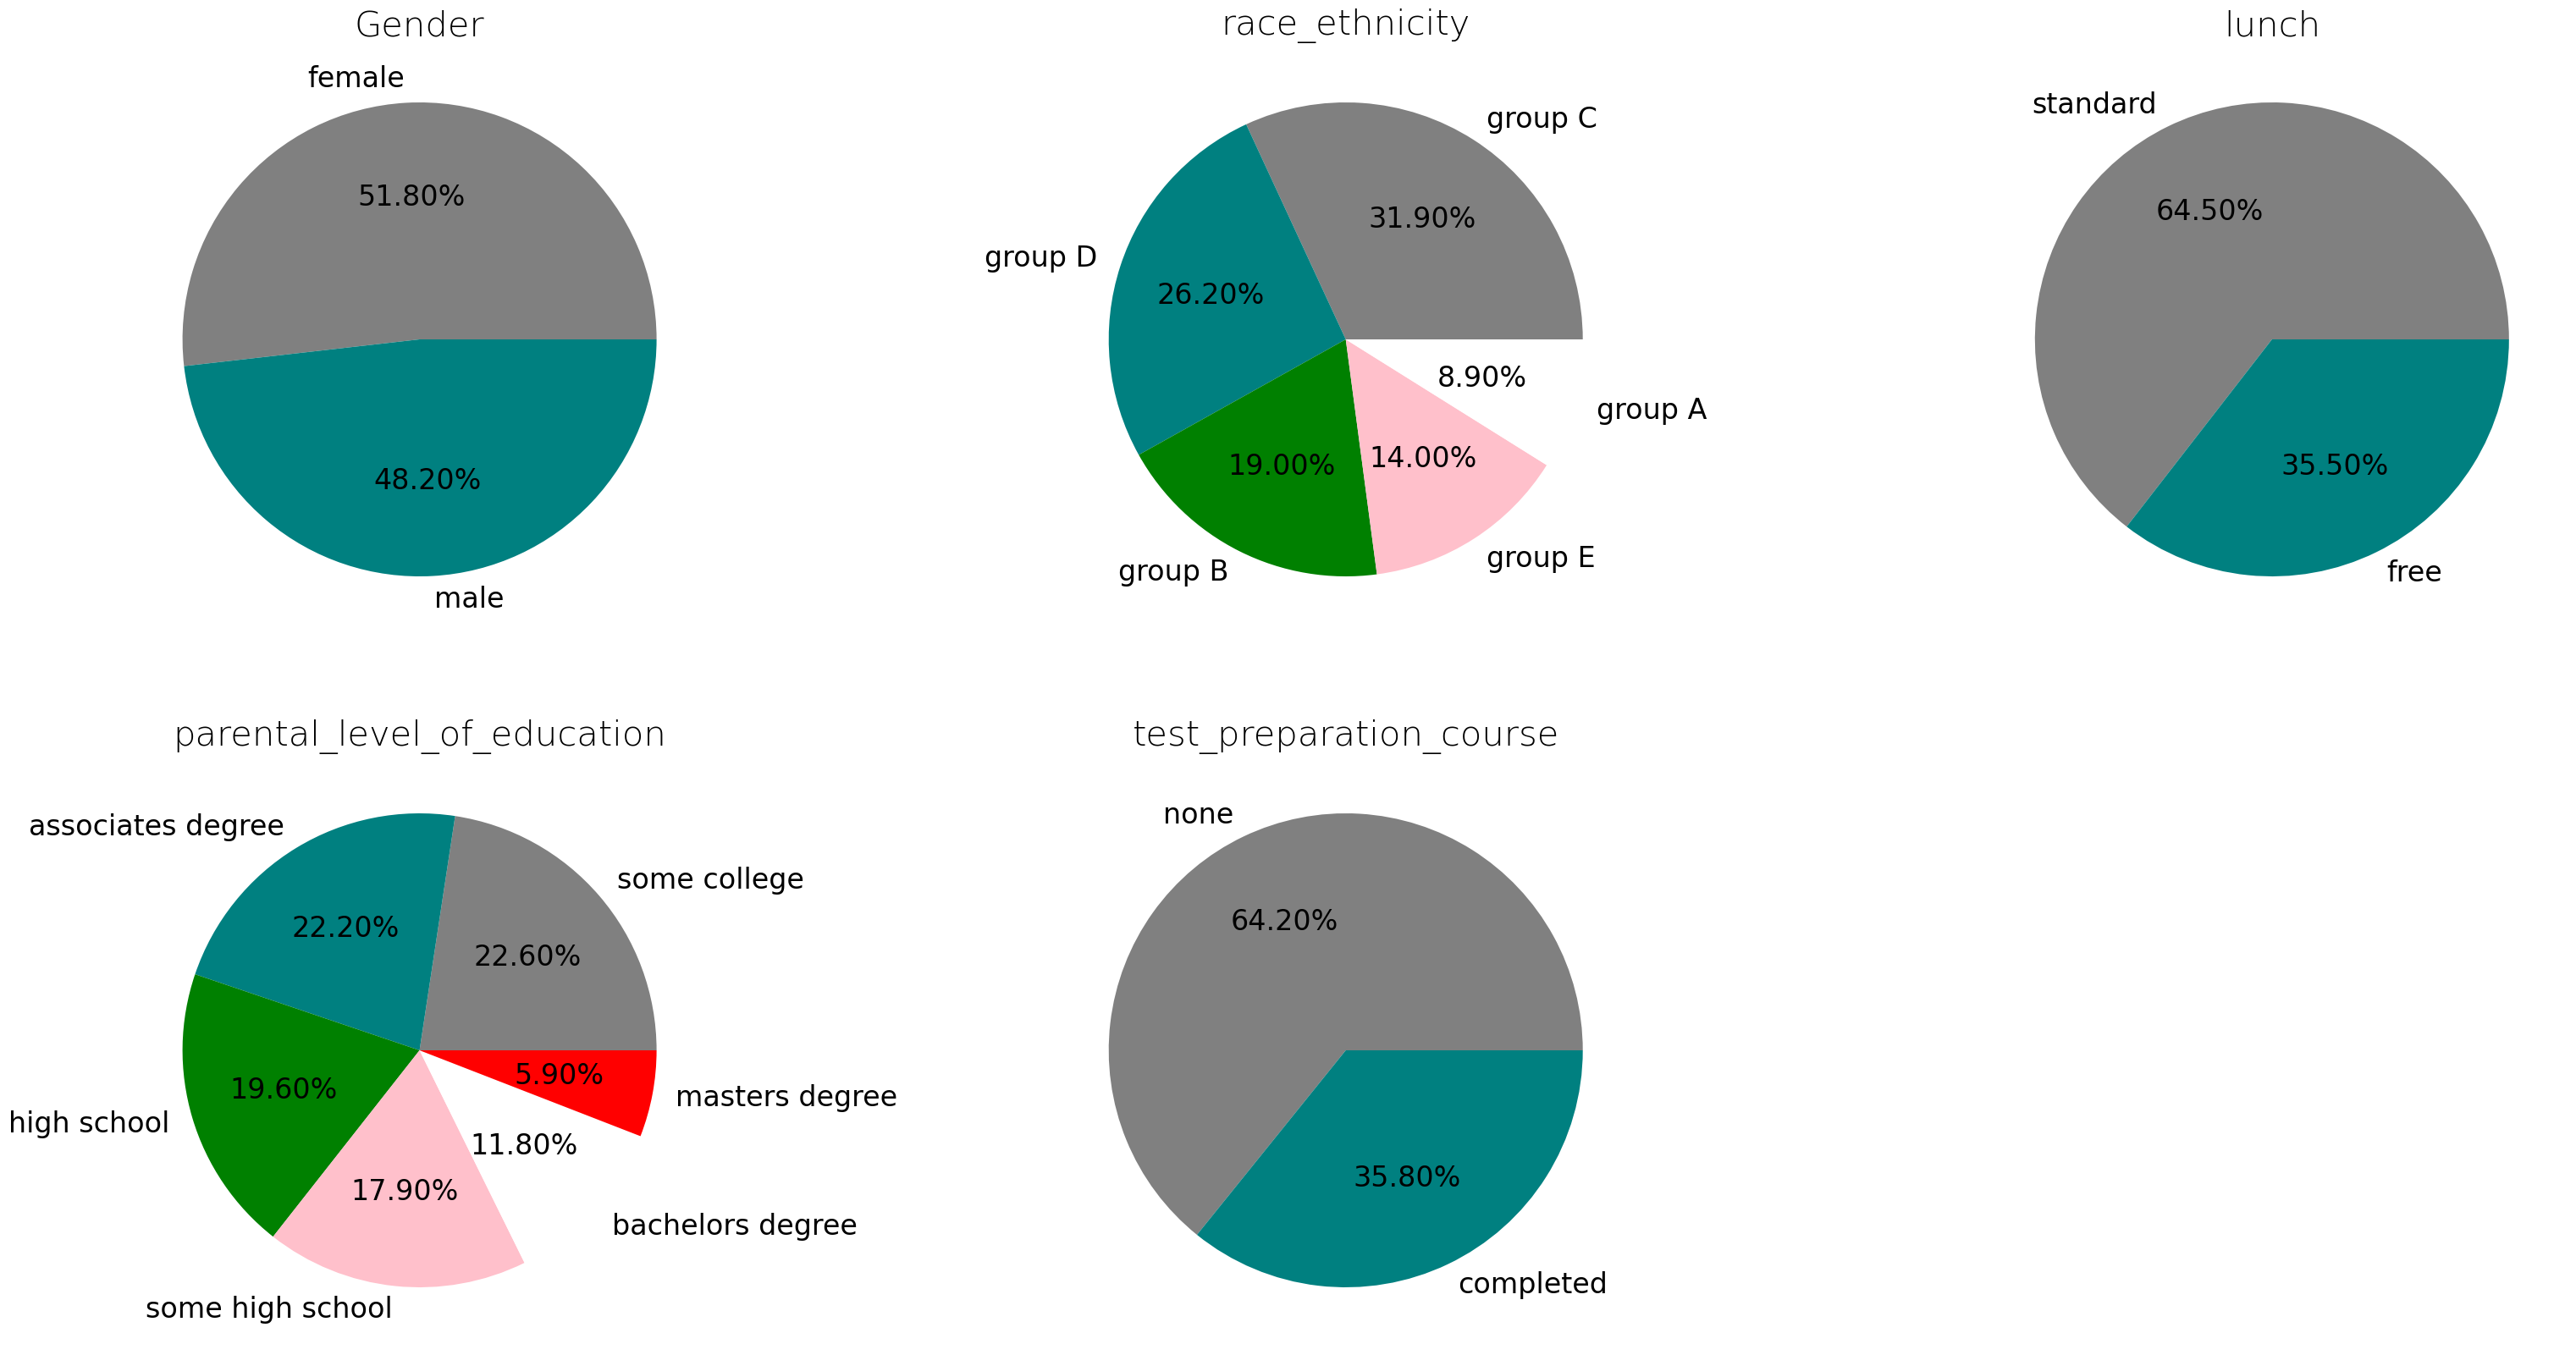

In [97]:
plt.rcParams['figure.figsize'] =(40,20)
plt.rcParams['font.size'] = 24

plt.subplot(2,3,1)
size = df['gender'].value_counts()
labels = ['female', 'male']
colors = ['grey' , 'teal']
plt.pie(size , labels=labels , colors =colors , autopct = '%.2f%%')
plt.title('Gender' , fontsize=30 ,fontweight=30)

plt.subplot(2,3,2)
size = df['race_ethnicity'].value_counts()
labels = ['group C', 'group D', 'group B', 'group E', 'group A']
colors = ['grey' , 'teal'  , 'green' , 'pink','white']
plt.pie(size , labels=labels , colors =colors , autopct = '%.2f%%')
plt.title('race_ethnicity' , fontsize=30 ,fontweight=30)


plt.subplot(2,3,3)
size = df['lunch'].value_counts()
labels = ['standard' ,'free']
colors = ['grey' , 'teal' ]
plt.pie(size , labels=labels , colors =colors , autopct = '%.2f%%')
plt.title('lunch' , fontsize=30 ,fontweight=30)

plt.subplot(2,3,4)
size = df['parental_level_of_education'].value_counts()
labels = ['some college ', 'associates degree', 'high school', 'some high school', 'bachelors degree' ,'masters degree']
colors = ['grey' , 'teal'  , 'green' , 'pink','white' , 'red']
plt.pie(size , labels=labels , colors =colors , autopct = '%.2f%%')
plt.title('parental_level_of_education' , fontsize=30 ,fontweight=30)


plt.subplot(2,3,5)
size = df['test_preparation_course'].value_counts()
labels = ['none' ,'completed']
colors = ['grey' , 'teal' ]
plt.pie(size , labels=labels , colors =colors , autopct = '%.2f%%')
plt.title('test_preparation_course' , fontsize=30 ,fontweight=30)

plt.show()

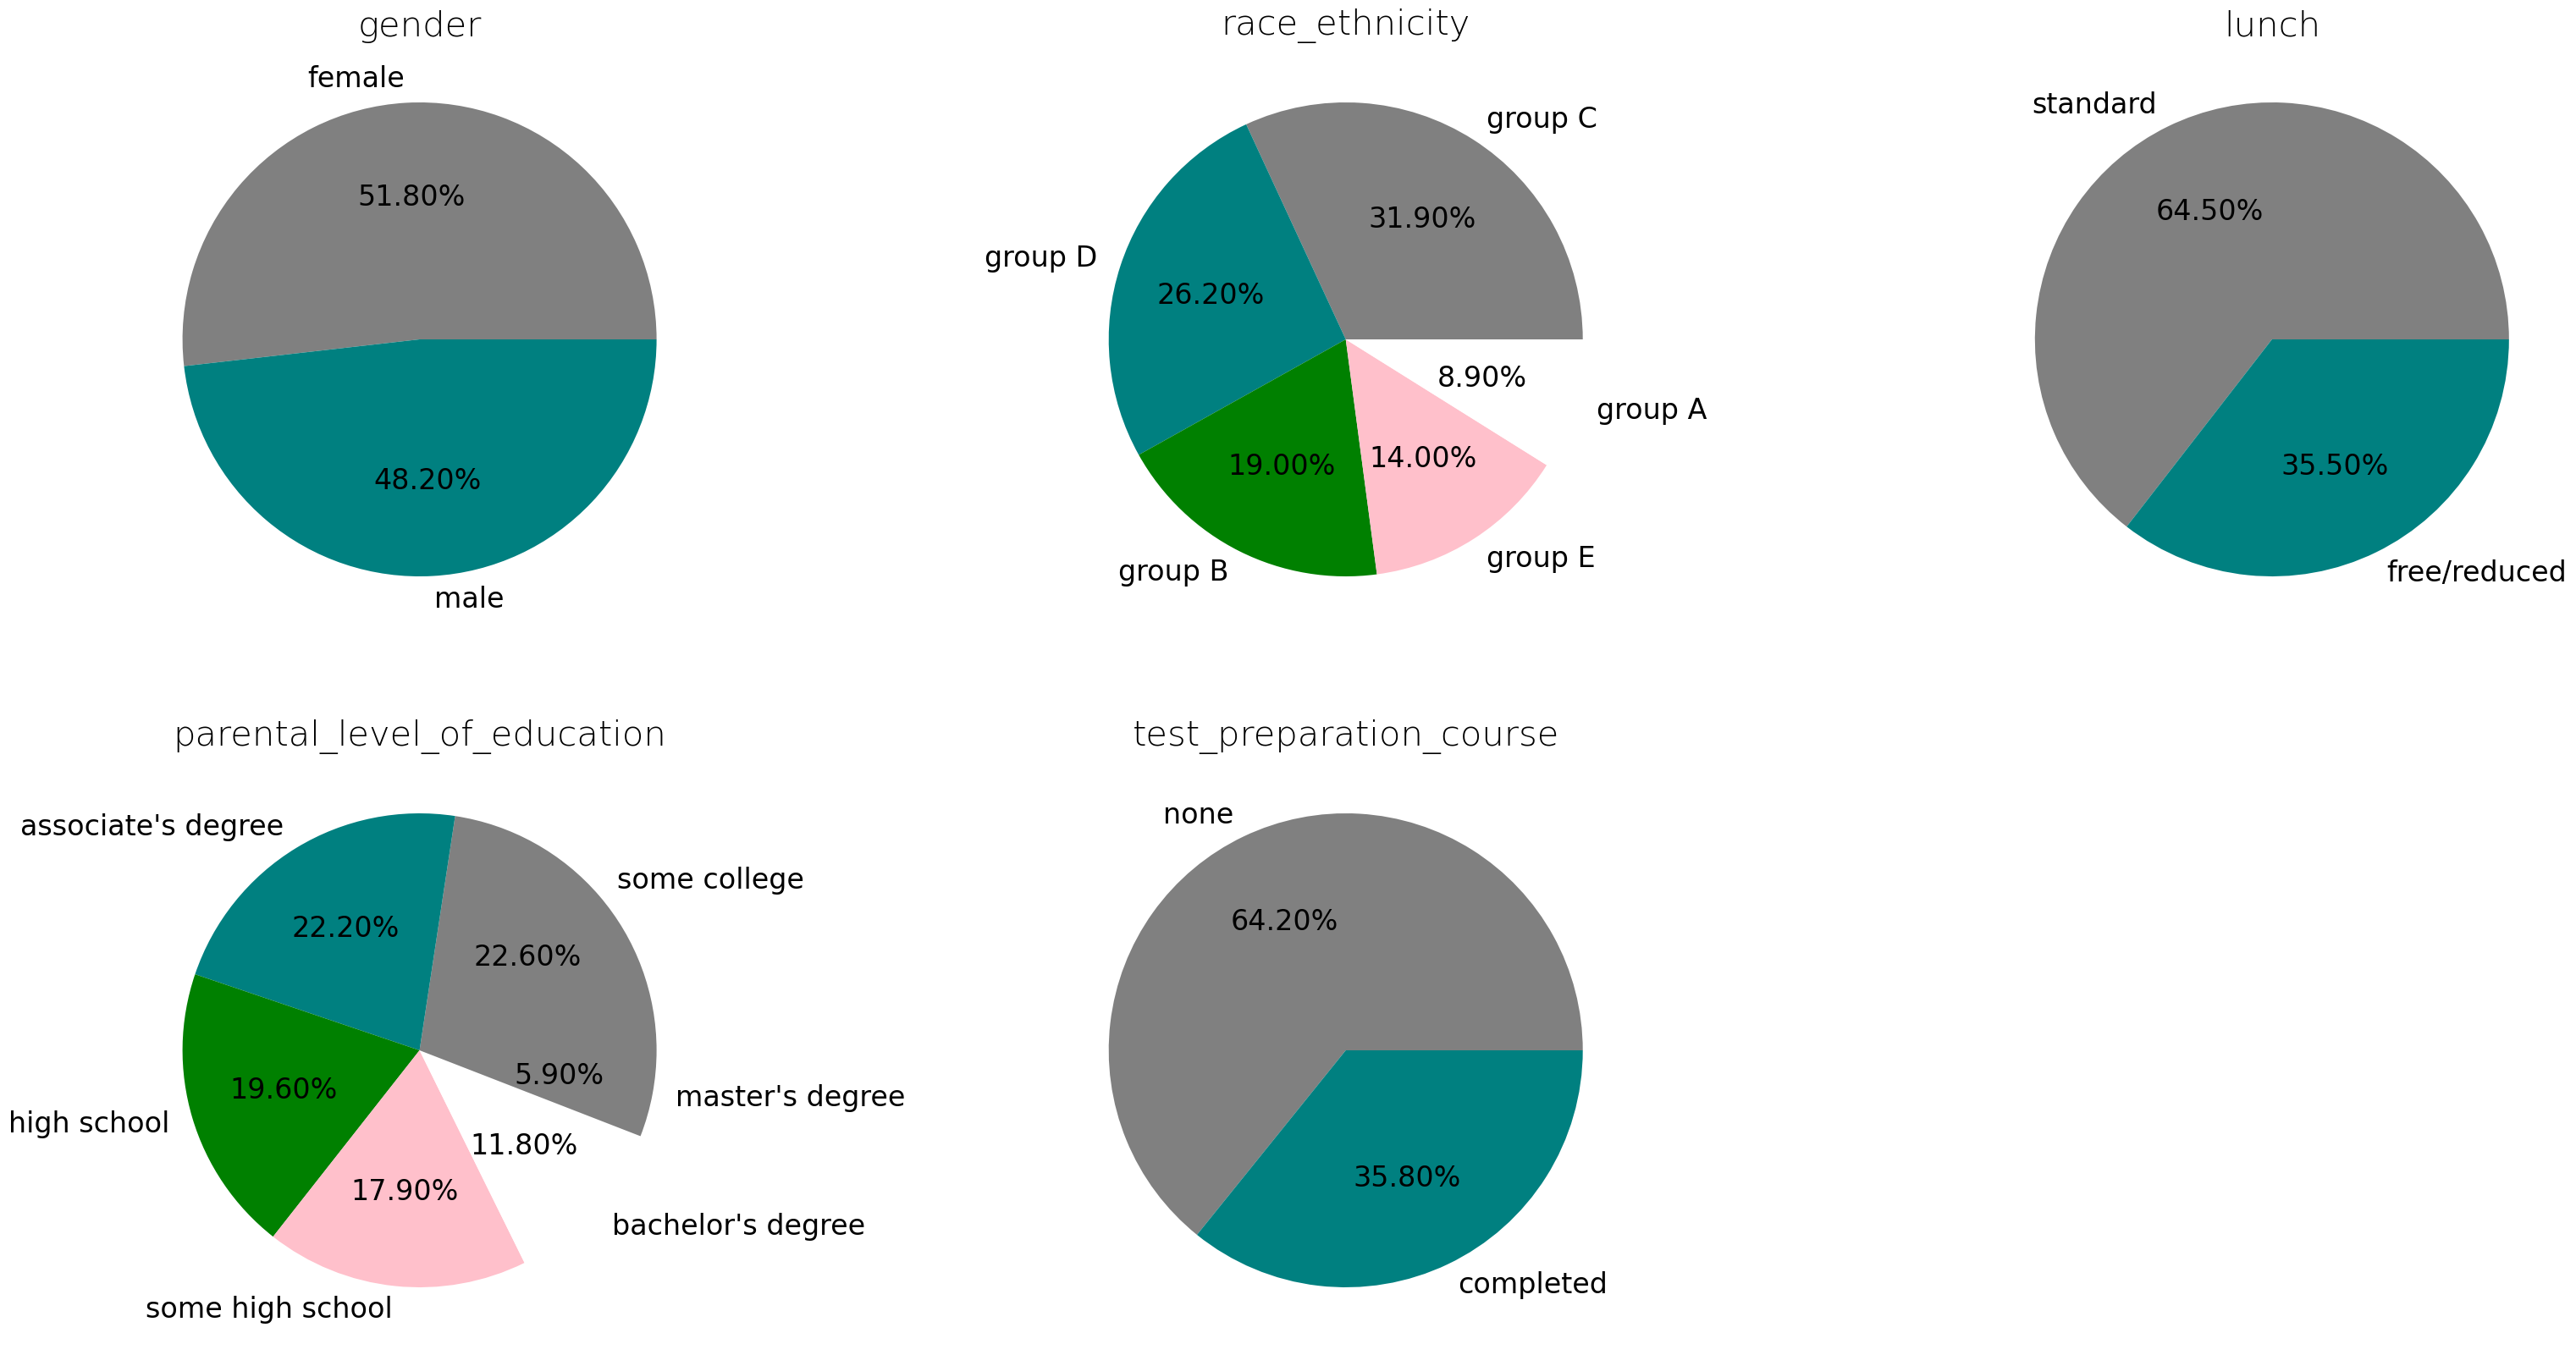

In [107]:
plt.rcParams['figure.figsize'] = (40, 20)
plt.rcParams['font.size'] = 24

cols = [
    'gender',
    'race_ethnicity',
    'lunch',
    'parental_level_of_education',
    'test_preparation_course'
]

colors = ['grey', 'teal', 'green', 'pink', 'white', 'red']

for i, col in enumerate(cols, 1):
    plt.subplot(2,3,i)
    size = df[col].value_counts()
    labels = size.index
    colors =colors[:len(col)]
    plt.pie(size , labels= labels , colors=colors ,autopct = '%.2f%%')
    plt.title(col, fontsize=30 ,fontweight=30)
plt.show()

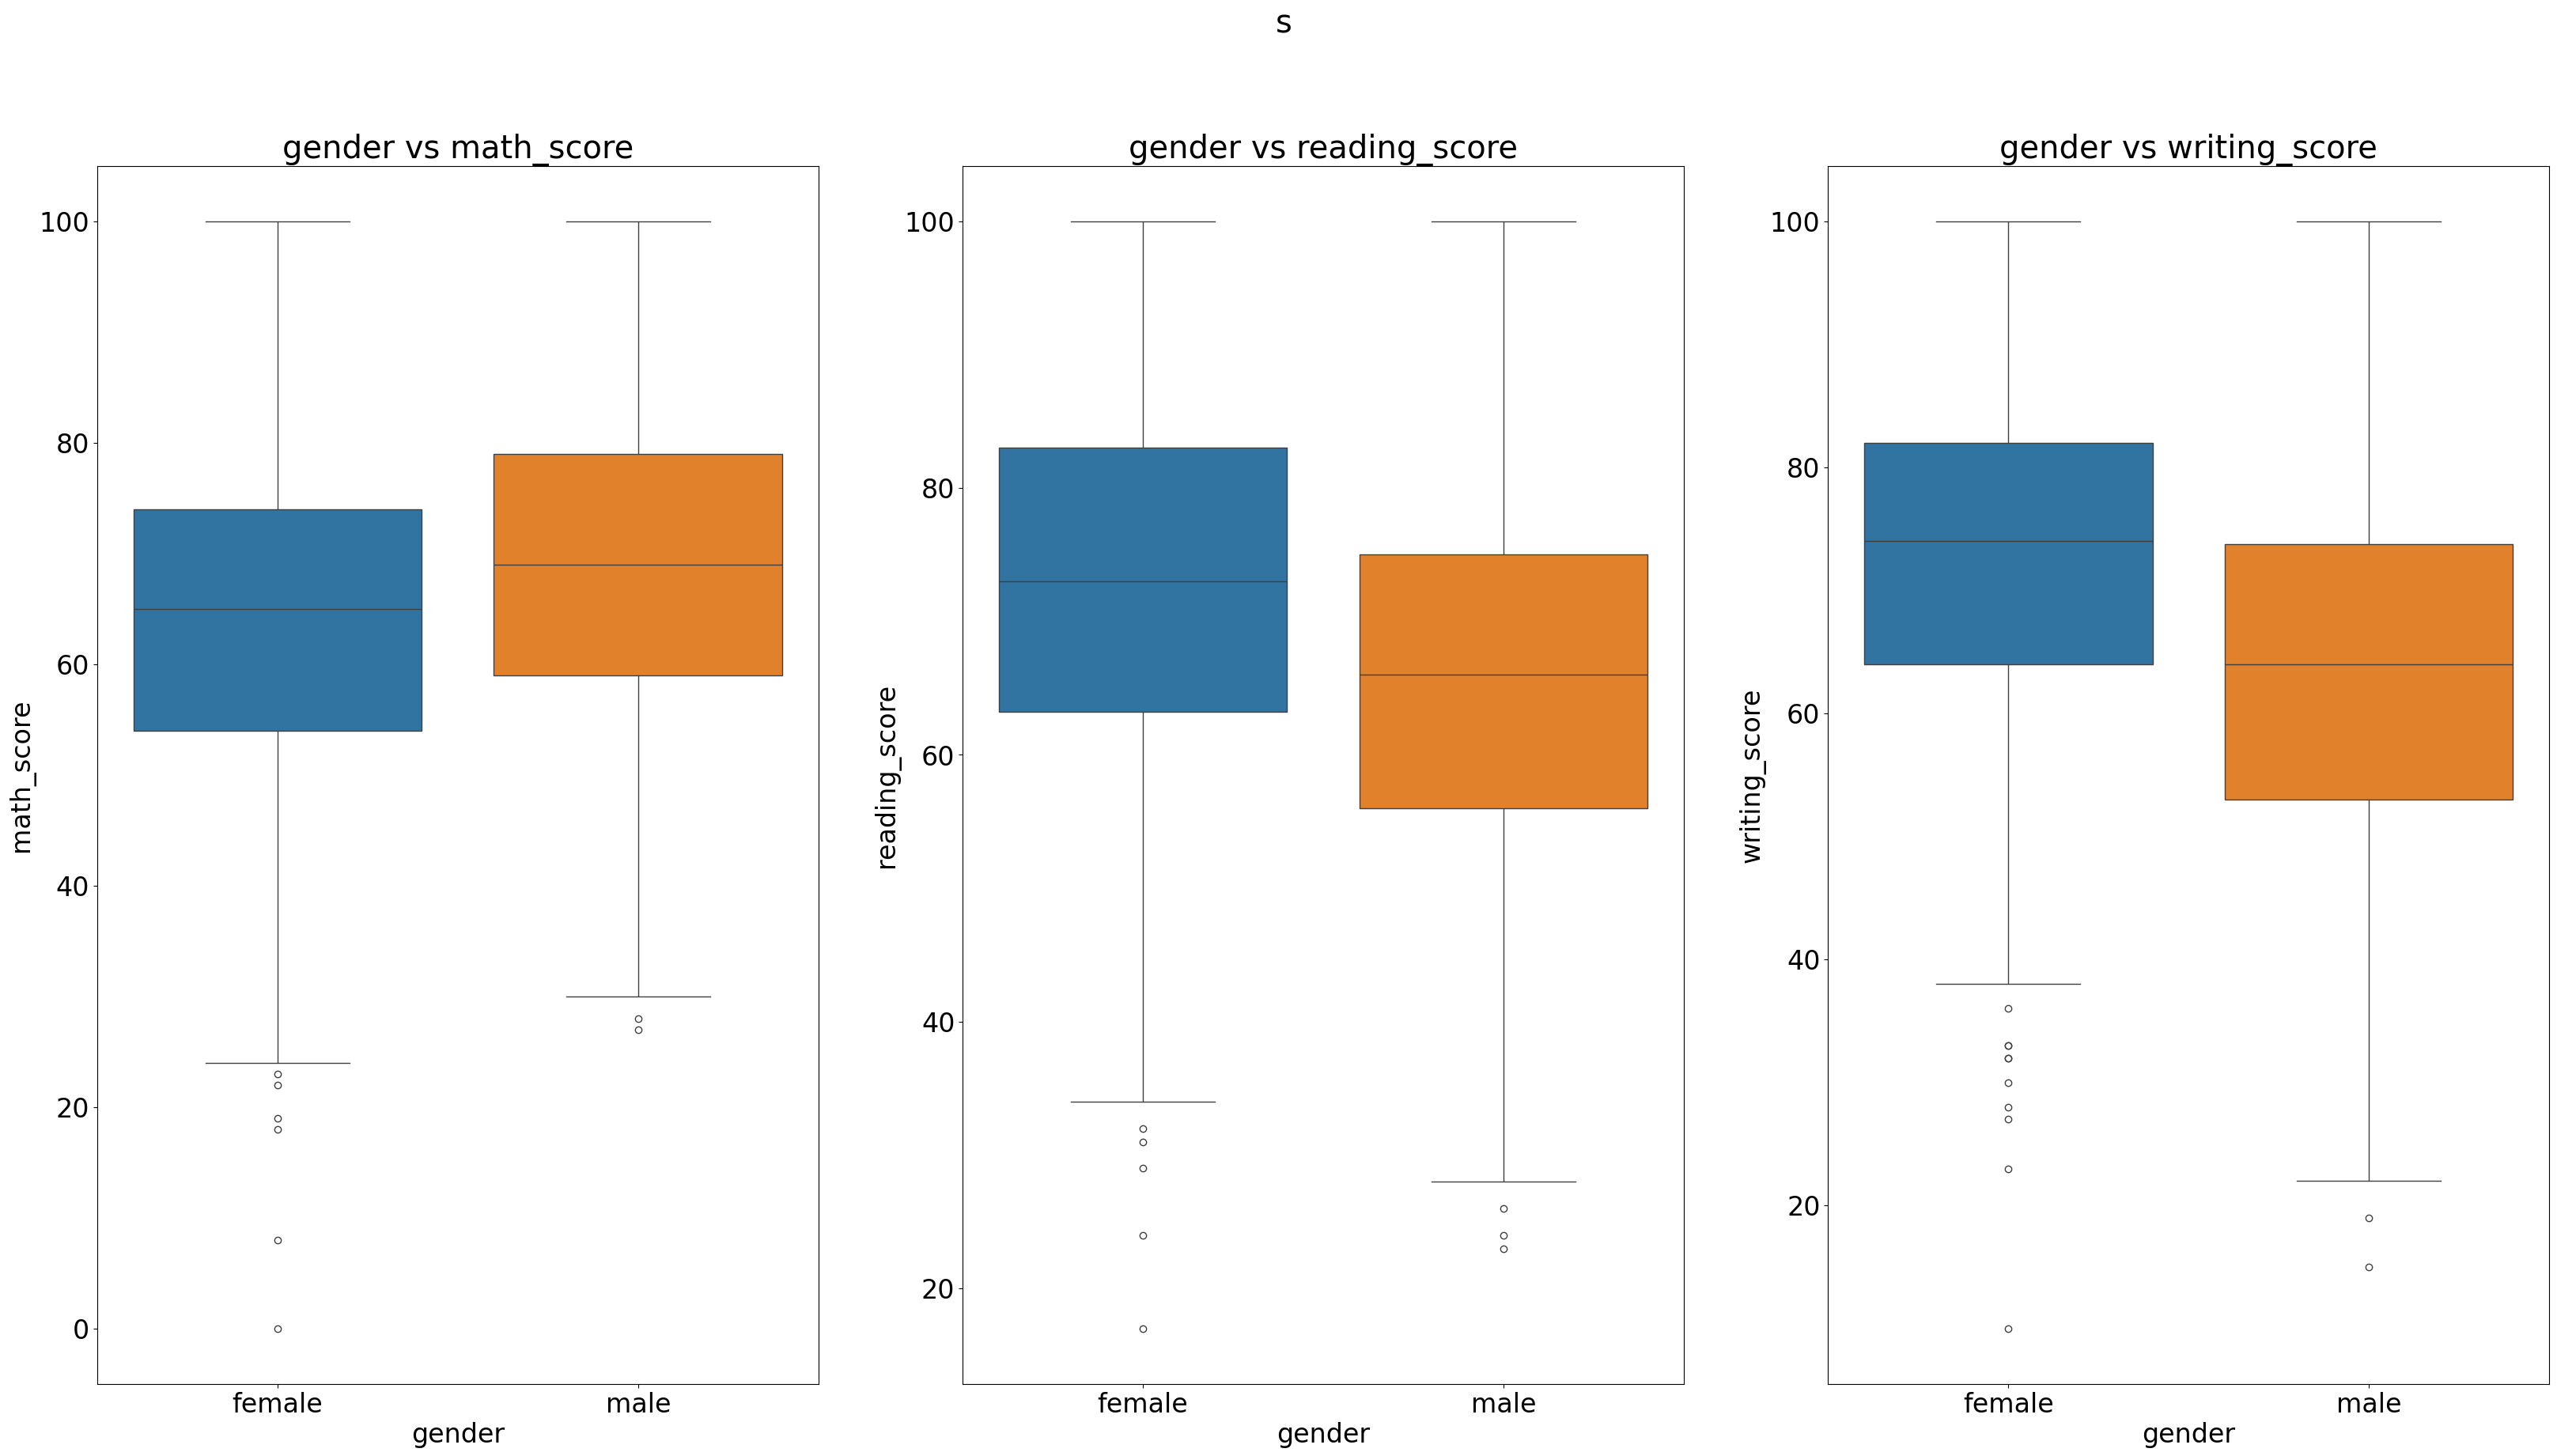

In [132]:
fig , ax = plt.subplots(1,3)
fig.suptitle('s')

sns.boxplot(x='gender' , y='math_score' , data=df , ax=ax[0] ,hue='gender')
ax[0].title.set_text('gender vs math_score')

sns.boxplot(x='gender' , y='reading_score' , data=df , ax=ax[1] ,hue='gender')
ax[1].title.set_text('gender vs reading_score')

sns.boxplot(x='gender' , y='writing_score' , data=df , ax=ax[2],hue='gender')
ax[2].title.set_text('gender vs writing_score')
    


C:\Users\PC_KH\AppData\Local\Temp\ipykernel_28460\2314145882.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  var1 =ax[0].set_xticklabels(ax[0].get_xticklabels() ,rotation =30)
C:\Users\PC_KH\AppData\Local\Temp\ipykernel_28460\2314145882.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  var1 =ax[1].set_xticklabels(ax[1].get_xticklabels() ,rotation =30)
C:\Users\PC_KH\AppData\Local\Temp\ipykernel_28460\2314145882.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  var1 =ax[2].set_xticklabels(ax[2].get_xticklabels() ,rotation =30)


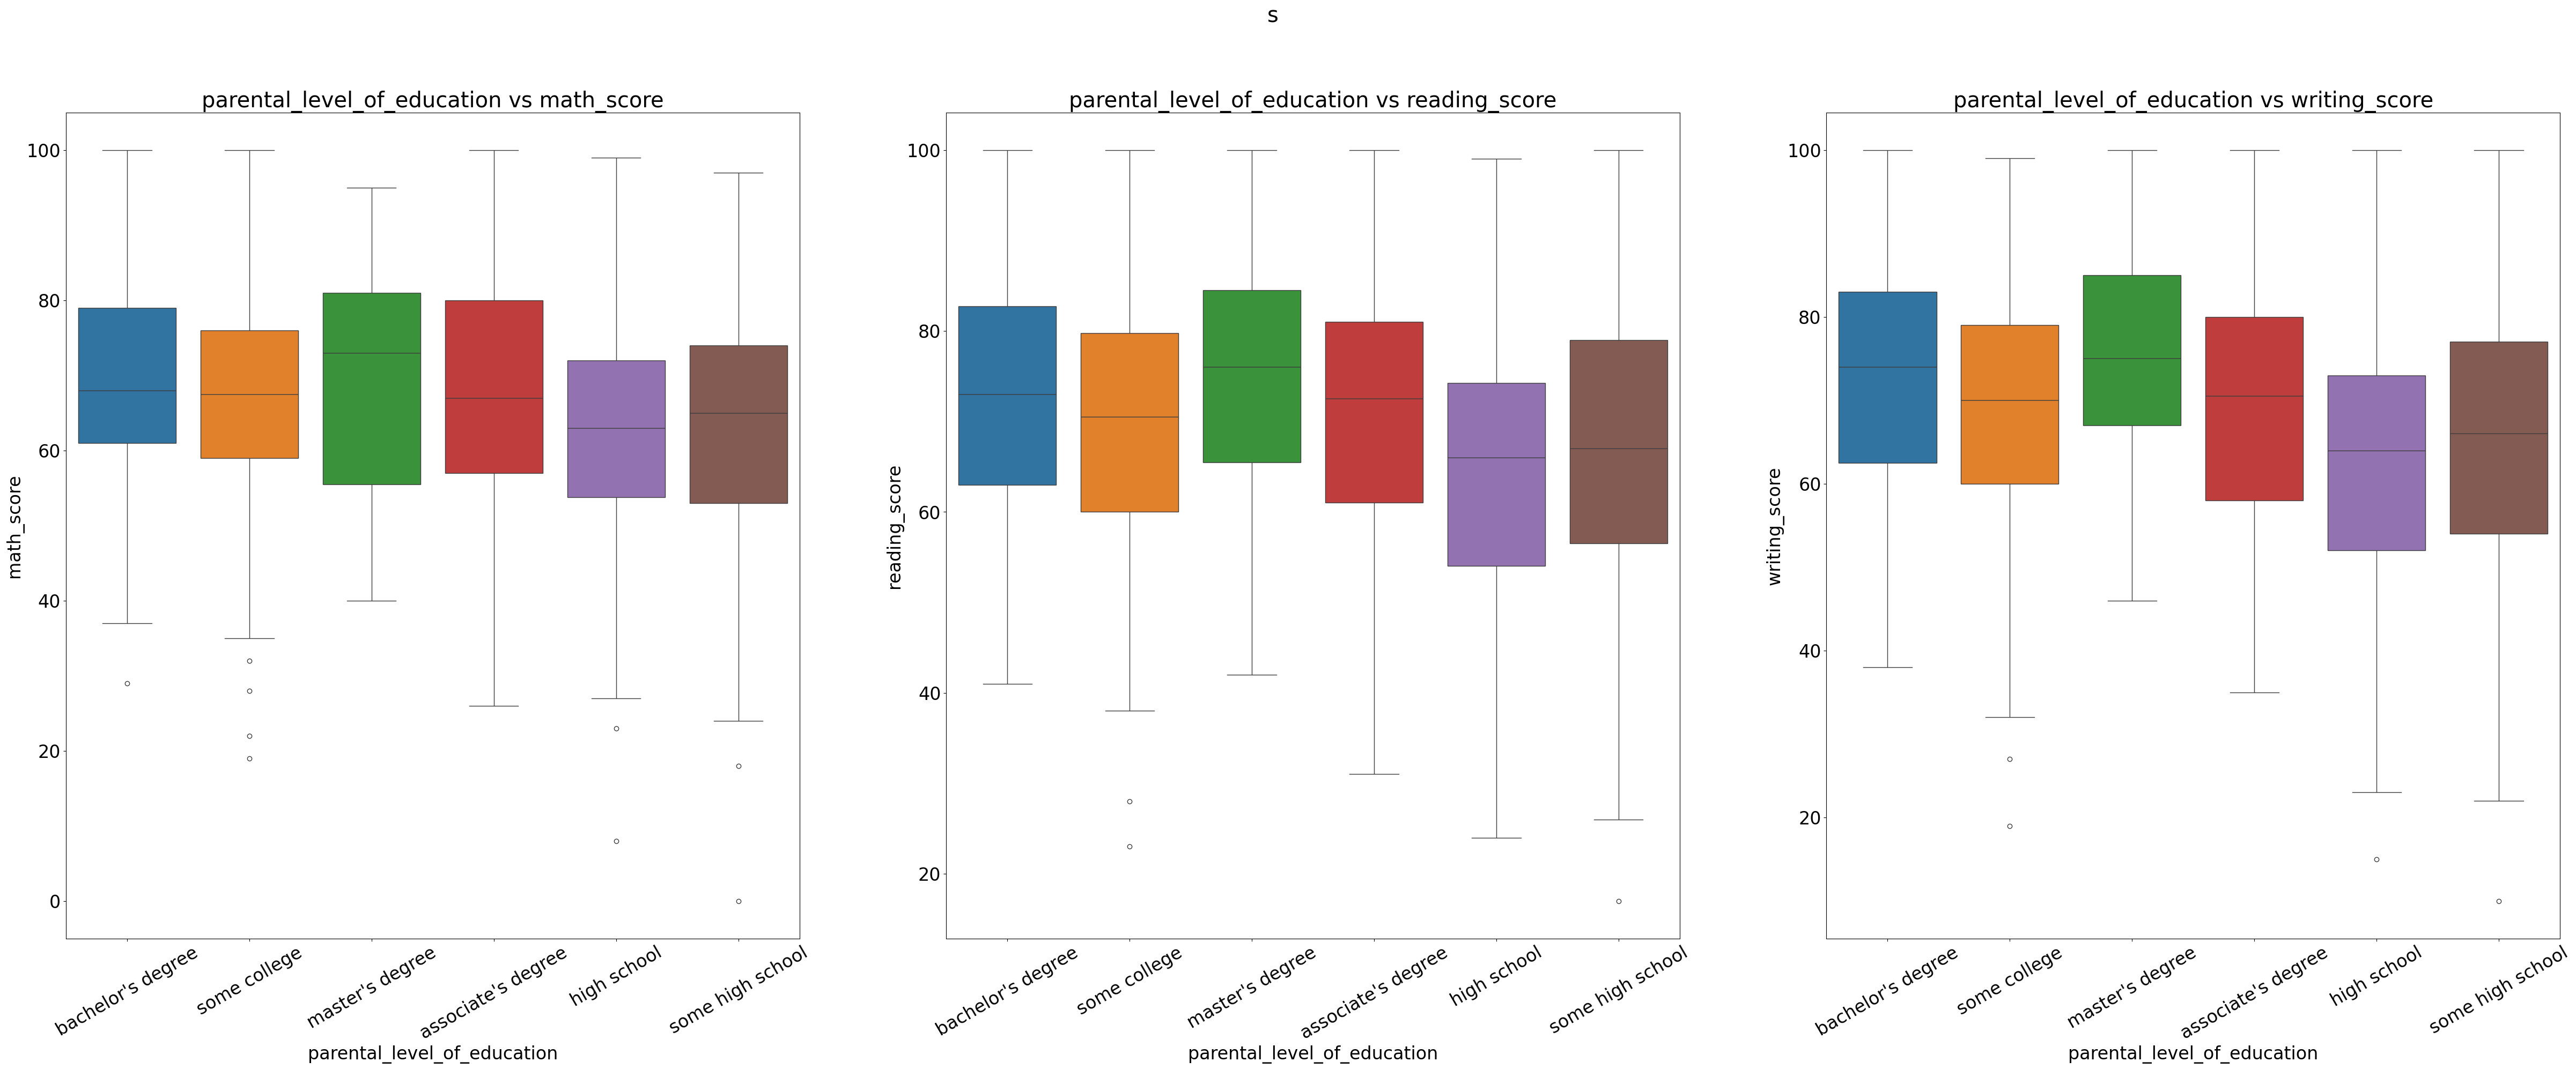

In [142]:

plt.rcParams['figure.figsize'] = (60, 20)
plt.rcParams['font.size'] = 24
fig , ax = plt.subplots(1,3)
fig.suptitle('s')

sns.boxplot(x='parental_level_of_education' , y='math_score' , data=df , ax=ax[0] ,hue='parental_level_of_education')
ax[0].title.set_text('parental_level_of_education vs math_score')
var1 =ax[0].set_xticklabels(ax[0].get_xticklabels() ,rotation =30)

sns.boxplot(x='parental_level_of_education' , y='reading_score' , data=df , ax=ax[1] ,hue='parental_level_of_education')
ax[1].title.set_text('parental_level_of_education vs reading_score')
var1 =ax[1].set_xticklabels(ax[1].get_xticklabels() ,rotation =30)

sns.boxplot(x='parental_level_of_education' , y='writing_score' , data=df , ax=ax[2],hue='parental_level_of_education')
ax[2].title.set_text('parental_level_of_education vs writing_score')
var1 =ax[2].set_xticklabels(ax[2].get_xticklabels() ,rotation =30)
